<a href="https://colab.research.google.com/github/Codewithtanvi/House-Price-Prediction-/blob/main/Day6_Advanced_Analytics_%26_Risk_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

# Load the nav_df DataFrame from the CSV file
nav_df = pd.read_csv('02_nav_history.csv')

# Load the fund master data to get scheme names
fund_master_df = pd.read_csv('01_fund_master.csv')

# Merge nav_df with fund_master_df to get scheme_name
nav_df = pd.merge(nav_df, fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Ensure 'date' column is in datetime format for proper sorting
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Daily returns
nav_df = nav_df.sort_values(['scheme_name', 'date'])

nav_df['daily_return'] = (
    nav_df.groupby('scheme_name')['nav']
          .pct_change()
)

risk_metrics = []

for scheme, group in nav_df.groupby('scheme_name'):

    returns = group['daily_return'].dropna()

    if len(returns) > 50:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[returns <= var95].mean()

        risk_metrics.append([
            scheme,
            var95,
            cvar95
        ])

var_cvar_df = pd.DataFrame(
    risk_metrics,
    columns=['scheme_name','VaR_95','CVaR_95']
)

var_cvar_df.to_csv(
    'var_cvar_report.csv',
    index=False
)

print(var_cvar_df.head())

                                     scheme_name    VaR_95   CVaR_95
0  ABSL Frontline Equity Fund - Regular - Growth -0.013282 -0.017439
1            ABSL Liquid Fund - Regular - Growth -0.000269 -0.000422
2         ABSL Small Cap Fund - Regular - Growth -0.026021 -0.032459
3           Axis Bluechip Fund - Direct - Growth -0.014226 -0.017487
4          Axis Bluechip Fund - Regular - Growth -0.013750 -0.017328


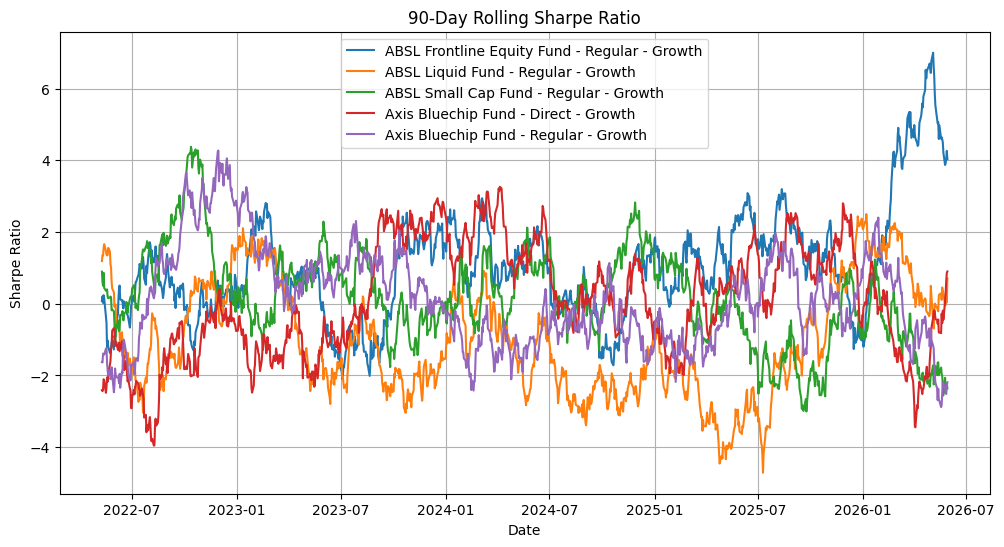

In [5]:
import matplotlib.pyplot as plt

risk_free_rate = 0.065

key_funds = [
    nav_df['scheme_name'].unique()[0],
    nav_df['scheme_name'].unique()[1],
    nav_df['scheme_name'].unique()[2],
    nav_df['scheme_name'].unique()[3],
    nav_df['scheme_name'].unique()[4]
]

plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav_df[
        nav_df['scheme_name'] == fund
    ].copy()

    returns = temp['daily_return']

    rolling_sharpe = (
        (returns.rolling(90).mean()*252 - risk_free_rate)
        /
        (returns.rolling(90).std()*np.sqrt(252))
    )

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=fund
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [8]:
import pandas as pd

sip_df = pd.read_csv('04_monthly_sip_inflows.csv')

# Convert 'month' to datetime, as 'transaction_date' is not present in this dataset.
sip_df['month'] = pd.to_datetime(
    sip_df['month']
)

# Define 'cohort_year' based on the year of the 'month' column,
# as 'investor_id' is not available for individual-level cohort analysis.
sip_df['cohort_year'] = sip_df['month'].dt.year

cohort_summary = (
    sip_df.groupby('cohort_year')
          .agg(
              # Using 'sip_inflow_crore' as the amount equivalent,
              # as 'amount' column is not available.
              avg_sip_amount_crore=('sip_inflow_crore','mean'),
              total_invested_crore=('sip_inflow_crore','sum')
          )
          .reset_index()
)

# The original code's calculation for 'top_fund' based on 'scheme_name'
# and subsequent merge cannot be performed with the current
# '04_monthly_sip_inflows.csv' dataset as it lacks 'scheme_name'.
# This section has been removed.
# top_fund = (
#     sip_df.groupby(
#         ['cohort_year','scheme_name']
#     )['amount']
#     .sum()
#     .reset_index()
# )
#
# top_fund = (
#     top_fund.sort_values(
#         ['cohort_year','amount'],
#         ascending=[True,False]
#     )
#     .groupby('cohort_year')
#     .first()
#     .reset_index()
# )
#
# cohort_summary = cohort_summary.merge(
#     top_fund[['cohort_year','scheme_name']],
#     on='cohort_year'
# )

print(cohort_summary)

   cohort_year  avg_sip_amount_crore  total_invested_crore
0         2022          12453.083333                149437
1         2023          15396.916667                184763
2         2024          22481.750000                269781
3         2025          27978.333333                335740


In [12]:
print(sip_df.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct', 'cohort_year']


In [14]:
import pandas as pd
import numpy as np

investor_df = pd.read_csv('08_investor_transactions.csv')

investor_df['transaction_date'] = pd.to_datetime(
    investor_df['transaction_date']
)

investor_df = investor_df.sort_values(
    ['investor_id','transaction_date']
)

eligible = (
    investor_df.groupby('investor_id')
          .filter(lambda x: len(x) >= 6)
)

eligible['gap_days'] = (
    eligible.groupby('investor_id')
            ['transaction_date']
            .diff()
            .dt.days
)

gap_summary = (
    eligible.groupby('investor_id')
            ['gap_days']
            .mean()
            .reset_index()
)

gap_summary['status'] = np.where(
    gap_summary['gap_days'] > 35,
    'At-Risk',
    'Active'
)

continuity_rate = (
    (gap_summary['status']=='Active')
    .mean()
    * 100
)

print(
    f"SIP Continuity Rate: {continuity_rate:.2f}%"
)

SIP Continuity Rate: 6.37%


In [20]:
import pandas as pd
import numpy as np

def recommend_funds(
    risk_appetite,
    sharpe_df,
    fund_master
):

    mapping = {
        'Low':'Low',
        'Moderate':'Moderate',
        'High':'High'
    }

    filtered = (
        sharpe_df.merge(
            fund_master[['scheme_name', 'risk_grade']], # Merge with relevant columns from fund_master
            on='scheme_name'
        )
    )

    filtered = filtered[
        filtered['risk_grade']
        ==
        mapping[risk_appetite]
    ]

    recommendations = (
        filtered.sort_values(
            'Sharpe',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        ['scheme_name',
         'Sharpe',
         'risk_grade']
    ]

# Calculate rolling Sharpe ratio for each fund and store it in a DataFrame
sharpe_data = []

for scheme, group in nav_df.groupby('scheme_name'):
    returns = group['daily_return'].dropna()
    if len(returns) > 90: # Ensure enough data points for rolling 90 days
        rolling_sharpe = (
            (returns.rolling(90).mean()*252 - risk_free_rate)
            /
            (returns.rolling(90).std()*np.sqrt(252))
        ).mean() # Take the mean of the rolling sharpe for a single value per fund
        sharpe_data.append([scheme, rolling_sharpe])

sharpe_df = pd.DataFrame(sharpe_data, columns=['scheme_name', 'Sharpe'])

# Add 'risk_grade' to fund_master_df based on 'risk_category'
def assign_risk_grade_from_category(category):
    if pd.isna(category):
        return 'Unknown'
    elif category == 'Low':
        return 'Low'
    elif category == 'Moderate':
        return 'Moderate'
    elif category == 'High' or category == 'Very High': # Assuming 'Very High' also maps to 'High' for simplicity
        return 'High'
    else:
        return 'Unknown'

fund_master_df['risk_grade'] = fund_master_df['risk_category'].apply(assign_risk_grade_from_category)

# Example
print(
    recommend_funds(
        'Moderate',
        sharpe_df,
        fund_master_df # Use fund_master_df which is already loaded
    )
)


                                      scheme_name    Sharpe risk_grade
25  Mirae Asset Large Cap Fund - Regular - Growth  1.425954   Moderate
33      SBI Bluechip Fund - Regular Plan - Growth  1.252184   Moderate
15      ICICI Pru Bluechip Fund - Direct - Growth  1.107818   Moderate


In [27]:
import pandas as pd

portfolio_df = pd.read_csv('09_portfolio_holdings.csv')

# Use 'weight_pct' and convert it to a decimal
portfolio_df['weight'] = (
    portfolio_df['weight_pct'] / 100
)

hhi = (
    portfolio_df.groupby('amfi_code') # Group by amfi_code instead of scheme_name
    ['weight']
    .apply(
        lambda x: (x**2).sum()
    )
    .reset_index()
)

hhi.columns = [
    'amfi_code', # Name the column 'amfi_code'
    'HHI'
]

print(
    hhi.sort_values(
        'HHI',
        ascending=False
    )
)


    amfi_code       HHI
11     119092  0.206448
3      101207  0.200700
18     119599  0.174751
4      102885  0.174709
7      118632  0.168298
29     148568  0.167930
21     120505  0.157570
22     120506  0.153794
27     125498  0.152414
23     120841  0.149680
30     148569  0.149396
1      100033  0.147592
32     149323  0.141621
19     120503  0.140870
0      100016  0.139534
28     148567  0.138584
26     125497  0.136586
13     119094  0.136406
10     118635  0.135944
31     149322  0.134398
12     119093  0.130894
6      102887  0.129805
2      101206  0.129332
25     120843  0.128683
24     120842  0.127439
8      118633  0.121461
15     119551  0.118716
33     149324  0.118677
5      102886  0.114693
14     119095  0.109605
20     120504  0.108674
9      118634  0.108358
16     119552  0.108011
17     119598  0.107349


# Advanced Analytics Insights

## 1. Downside Risk
Funds with the most negative VaR and CVaR values exhibit the highest downside risk and are more vulnerable during market stress periods.

## 2. Risk-Adjusted Performance
Funds consistently showing high rolling 90-day Sharpe ratios generated superior risk-adjusted returns relative to peers.

## 3. Investor Cohort Behaviour
Recent investor cohorts contribute the highest total investments, indicating growing participation in mutual fund SIPs.

## 4. SIP Continuity
A high SIP continuity rate reflects strong investor discipline. Investors with average gaps exceeding 35 days are classified as at-risk.

## 5. Portfolio Concentration
Funds with high HHI values have concentrated sector exposure and may experience greater volatility during sector-specific downturns.